point: 20001
freq range: 0.00 ~ 4.50 GHz
deltaf: 0.22 MHz
 Δt: 0.11 ns

时域分析结果:
时间分辨率 Δt: 0.11 ns


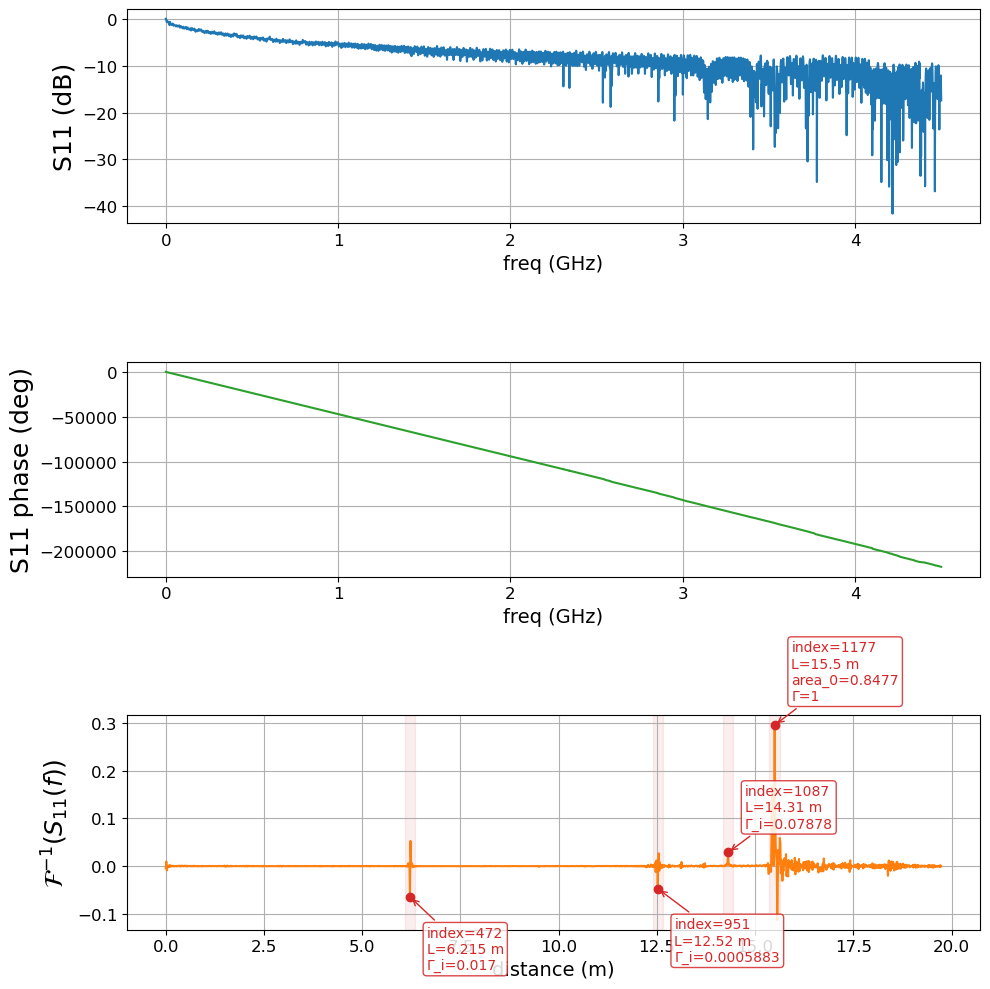

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import numpy as np
import pandas as pd
from IPython.display import display, Math

def TDR_function(s11real, s11imag, freq, use_abs=False):    # 对测量得到的S11作IFFT得到TDR
    """
    use_abs=False 返回带符号振幅；use_abs=True 返回振幅绝对值。
    如果输入缺少 0 Hz 频点，会自动补上 S11(0)=1+0j。
    """
    s11real = np.asarray(s11real)
    s11imag = np.asarray(s11imag)
    freq = np.asarray(freq)

    if len(s11real) != len(s11imag) or len(s11real) != len(freq):
        raise ValueError("s11real, s11imag, freq 的长度必须一致")
    if len(freq) < 2:
        raise ValueError("freq 至少需要两个点")

    sort_order = np.argsort(freq)
    freq = freq[sort_order]
    s11real = s11real[sort_order]
    s11imag = s11imag[sort_order]

    zero_freq_mask = np.isclose(freq, 0.0)
    if not np.any(zero_freq_mask):
        insert_pos = np.searchsorted(freq, 0.0)
        freq = np.insert(freq, insert_pos, 0.0)
        s11real = np.insert(s11real, insert_pos, 1.0)
        s11imag = np.insert(s11imag, insert_pos, 0.0)

    # 复数 S11
    S11 = s11real + 1j * s11imag
    N = len(S11)

    # 频率终点
    f_stop = freq[-1]

    # 时间分辨率：保持与你原单元格一致
    deltat = 1 / (2 * f_stop)

    # 反傅里叶变换
    time_domain_complex = np.fft.irfft(S11)

    # 保持与你原单元格一致，只取前 N 个点
    time_domain = time_domain_complex[:N]

    # 时域振幅
    mag_t = np.abs(time_domain) if use_abs else time_domain
    #vswr=(1+mag_t)/(1-mag_t)

    return deltat, mag_t

def TDR_peak_area(sequence, peak_count=3, peak_index_width=10, peak_by_abs=True, index_offset=0, sample_spacing=1.0, area_method='sum', ifft_length=None, epsilon_grid_count=401):
    """
    在一段 TDR 序列中按 abs(TDR) 找分立峰，并计算每个峰附近的等效面积。

    sequence 通常传入 plotTDR 截取后的 magt[index_min:index_max]。
    peak_index_width 表示峰中心左右各包含的 index 范围；默认 40，即正负 40。
    area_method='dirichlet_fit' 时，用离散 sinc/Dirichlet 模板拟合峰，拟合系数作为等效面积。
    area_method='sum' 时，area = sum(sequence[window])。
    abs(area) 最大的峰作为参考峰，记为 area_0，并令 Gamma=1。
    """
    y = np.asarray(sequence)

    if y.ndim != 1:
        raise ValueError("sequence 必须是一维数组")
    if peak_count < 1:
        raise ValueError("peak_count 必须大于等于 1")
    if peak_index_width < 1:
        raise ValueError("peak_index_width 必须大于等于 1")
    if area_method not in ('dirichlet_fit', 'sum'):
        raise ValueError("area_method 必须是 'dirichlet_fit' 或 'sum'")
    if epsilon_grid_count < 3:
        raise ValueError("epsilon_grid_count 必须大于等于 3")
    if len(y) == 0:
        return []
    if ifft_length is None:
        ifft_length = len(y)
    if ifft_length <= 0:
        raise ValueError("ifft_length 必须大于 0")

    peak_signal = np.abs(y) if peak_by_abs else y
    peak_signal = np.asarray(peak_signal, dtype=float)
    peak_signal = np.where(np.isfinite(peak_signal), peak_signal, -np.inf)

    if not np.any(np.isfinite(peak_signal)):
        return []

    if len(peak_signal) == 1:
        peak_rel_idx = np.array([0], dtype=int)
    elif len(peak_signal) == 2:
        peak_rel_idx = np.array([int(np.argmax(peak_signal))], dtype=int)
    else:
        local_peak_mask = (peak_signal[1:-1] >= peak_signal[:-2]) & (peak_signal[1:-1] >= peak_signal[2:])
        peak_rel_idx = np.where(local_peak_mask)[0] + 1
        edge_peaks = []
        if peak_signal[0] >= peak_signal[1]:
            edge_peaks.append(0)
        if peak_signal[-1] >= peak_signal[-2]:
            edge_peaks.append(len(peak_signal) - 1)
        if edge_peaks:
            peak_rel_idx = np.r_[peak_rel_idx, np.array(edge_peaks, dtype=int)]

    if len(peak_rel_idx) > 0:
        peak_rel_idx = peak_rel_idx[peak_signal[peak_rel_idx] > 0]

    if len(peak_rel_idx) == 0:
        max_rel_idx = int(np.argmax(peak_signal))
        if peak_signal[max_rel_idx] <= 0:
            return []
        peak_rel_idx = np.array([max_rel_idx], dtype=int)

    candidate_order = peak_rel_idx[np.argsort(peak_signal[peak_rel_idx])[::-1]]
    selected_rel_idx = []
    for rel_idx in candidate_order:
        if all(abs(int(rel_idx) - int(selected_idx)) >= 2 * peak_index_width for selected_idx in selected_rel_idx):
            selected_rel_idx.append(int(rel_idx))
        if len(selected_rel_idx) >= int(peak_count):
            break

    peak_infos = []
    half_width = int(peak_index_width)
    for rel_idx in selected_rel_idx:
        window_start = max(0, rel_idx - half_width)
        window_end = min(len(y), rel_idx + half_width + 1)
        window_y = y[window_start:window_end]
        peak_sum = np.sum(window_y)

        if area_method == 'dirichlet_fit':
            m = np.arange(window_start, window_end, dtype=float)
            y_fit = np.real(window_y).astype(float)
            eps_grid = np.linspace(-0.5, 0.5, int(epsilon_grid_count))
            best_loss = np.inf
            best_area = np.nan
            best_epsilon = 0.0
            for epsilon in eps_grid:
                u = m - rel_idx - epsilon
                template = np.sinc(u) / np.sinc(u / ifft_length)
                denom = np.dot(template, template)
                if denom <= 0:
                    continue
                area_candidate = np.dot(y_fit, template) / denom
                residual = y_fit - area_candidate * template
                loss = np.dot(residual, residual)
                if loss < best_loss:
                    best_loss = loss
                    best_area = area_candidate
                    best_epsilon = epsilon
            peak_area = best_area
        else:
            peak_area = peak_sum
            best_epsilon = 0.0
            best_loss = np.nan
        peak_infos.append({
            'rel_idx': int(rel_idx),
            'index': int(index_offset + rel_idx),
            'height': y[rel_idx],
            'sum': peak_sum,
            'area': peak_area,
            'epsilon': best_epsilon,
            'fit_loss': best_loss,
            'area_method': area_method,
            'window_start': int(window_start),
            'window_end': int(window_end),
            'window_start_index': int(index_offset + window_start),
            'window_end_index': int(index_offset + window_end),
        })

    if peak_infos:
        area_values = np.asarray([info['area'] for info in peak_infos], dtype=float)
        reference_pos = int(np.argmax(np.abs(area_values)))
        area_0 = area_values[reference_pos]
        for pos, info in enumerate(peak_infos):
            info['area_0'] = area_0
            info['is_reference'] = (pos == reference_pos)
            info['gamma'] = info['area'] / area_0 if area_0 != 0 else np.nan

    return peak_infos

def plotTDR(deltat, magt, s11real, s11imag, freq, beta, x_axis='index', index_max=1500, index_min=0, c=3e8, annotate_peaks=True, peak_count=3, peak_by_abs=True, peak_index_width=10, show_peak_window=True, peak_area_method='sum', peak_fit_grid_count=401, peaks_before_main=True, annotate_main_peak=True):   #  绘制|S11(f)|，S11相位，TDR 的结果
    magt = np.asarray(magt)
    freq = np.asarray(freq)
    s11real = np.asarray(s11real)
    s11imag = np.asarray(s11imag)
    N = len(magt)

    if deltat <= 0:
        raise ValueError("deltat 必须大于 0")
    if beta <= 0:
        raise ValueError("beta 必须大于 0")
    if peak_count < 1:
        raise ValueError("peak_count 必须大于等于 1")
    if peak_index_width < 1:
        raise ValueError("peak_index_width 必须大于等于 1")
    if peak_area_method not in ('dirichlet_fit', 'sum'):
        raise ValueError("peak_area_method 必须是 'dirichlet_fit' 或 'sum'")
    if peak_fit_grid_count < 3:
        raise ValueError("peak_fit_grid_count 必须大于等于 3")
    if x_axis not in ('index', 'distance'):
        raise ValueError("x_axis 必须是 'index' 或 'distance'")
    if len(s11real) != len(s11imag) or len(s11real) != len(freq):
        raise ValueError("s11real, s11imag, freq 的长度必须一致")
    if not 0 <= index_min < N:
        raise ValueError("index_min 必须在 TDR 数据范围内")

    index_max = min(int(index_max), N)
    index_min = int(index_min)
    if index_max <= index_min:
        raise ValueError("index_max 必须大于 index_min")

    S11 = s11real + 1j * s11imag
    
    # 频域幅度，单位 dB
    S11_mag_dB = 20 * np.log10(np.abs(S11) + 1e-20)
    S11_phase = np.angle(S11)                 # 先得到弧度制相位
    S11_phase_unwrap = np.unwrap(S11_phase)   # 相位展开，变连续
    S11_phase_deg = np.rad2deg(S11_phase_unwrap)
    fig, axes = plt.subplots(3, 1, figsize=(10, 10))

    # 第一个图：S 参数 振幅
    axes[0].plot(freq / 1e9, S11_mag_dB, color='C0')
    axes[0].set_xlabel('freq (GHz)', fontsize=14)
    axes[0].set_ylabel('S11 (dB)', fontsize=18)
    axes[0].tick_params(axis='both', labelsize=12)
    axes[0].grid(True)

    # 第二个图：S 参数 相位
    axes[1].plot(freq / 1e9, S11_phase_deg, color='C2')
    axes[1].set_xlabel('freq (GHz)', fontsize=14)
    axes[1].set_ylabel('S11 phase (deg)',fontsize=18)
    axes[1].tick_params(axis='both', labelsize=12)
    axes[1].grid(True)


    # 第三个图：TDR
    tdr_index = np.arange(index_min, index_max)
    if x_axis == 'distance':
        # 每个 index 对应的往返时间为 index * deltat，所以距离 L = v * t / 2。
        x_tdr = tdr_index * beta * c * deltat / 2
        x_label = 'distance (m)'
    else:
        x_tdr = tdr_index
        x_label = 'index'
    y_tdr = magt[index_min:index_max]
    axes[2].plot(x_tdr, y_tdr, color='C1', zorder=2)

    if annotate_peaks and len(y_tdr) > 0:
        main_signal = np.abs(magt) if peak_by_abs else magt
        main_signal = np.asarray(main_signal, dtype=float)
        main_signal = np.where(np.isfinite(main_signal), main_signal, -np.inf)
        main_peak_idx = int(np.argmax(main_signal))

        main_infos = TDR_peak_area(
            magt,
            peak_count=1,
            peak_index_width=peak_index_width,
            peak_by_abs=peak_by_abs,
            index_offset=0,
            area_method=peak_area_method,
            ifft_length=2 * (N - 1),
            epsilon_grid_count=peak_fit_grid_count,
        )
        main_info = main_infos[0] if len(main_infos) > 0 else None
        area_0 = main_info['area'] if main_info is not None else np.nan

        main_protect_end = max(index_min, main_peak_idx - int(peak_index_width))
        search_end_index = min(index_max, main_protect_end) if peaks_before_main else index_max
        if search_end_index > index_min:
            peak_infos = TDR_peak_area(
                magt[index_min:search_end_index],
                peak_count=peak_count,
                peak_index_width=peak_index_width,
                peak_by_abs=peak_by_abs,
                index_offset=index_min,
                area_method=peak_area_method,
                ifft_length=2 * (N - 1),
                epsilon_grid_count=peak_fit_grid_count,
            )
        else:
            peak_infos = []

        if main_info is not None:
            for peak_info in peak_infos:
                peak_info['area_0'] = area_0
                peak_info['is_reference'] = False
                peak_info['gamma'] = peak_info['area'] / area_0 if area_0 != 0 else np.nan

        if annotate_main_peak and main_info is not None and index_min <= main_peak_idx < index_max:
            main_info = dict(main_info)
            main_info['index'] = main_peak_idx
            main_info['rel_idx'] = main_peak_idx - index_min
            main_info['height'] = magt[main_peak_idx]
            main_info['area_0'] = area_0
            main_info['is_reference'] = True
            main_info['gamma'] = 1.0
            peak_infos = [main_info] + peak_infos

        for peak_info in peak_infos:
            rel_idx = peak_info['rel_idx']
            peak_idx = peak_info['index']
            peak_x = x_tdr[rel_idx]
            peak_y = peak_info['height']
            area_0 = peak_info['area_0']
            gamma_i = peak_info['gamma']

            if show_peak_window:
                peak_left_idx = peak_info['window_start_index']
                peak_right_idx = peak_info['window_end_index'] - 1
                if x_axis == 'distance':
                    peak_left_x = peak_left_idx * beta * c * deltat / 2
                    peak_right_x = peak_right_idx * beta * c * deltat / 2
                else:
                    peak_left_x = peak_left_idx
                    peak_right_x = peak_right_idx
                axes[2].axvspan(peak_left_x, peak_right_x, color='C3', alpha=0.08, zorder=1)

            axes[2].scatter([peak_x], [peak_y], color='C3', zorder=5)
            if peak_info['is_reference']:
                gamma_text = f"area_0={area_0:.4g}\nΓ=1"
            else:
                gamma_text = f"Γ_i={gamma_i:.4g}"
            if x_axis == 'distance':
                peak_text = f"index={peak_idx}\nL={peak_x:.4g} m\n{gamma_text}"
            else:
                peak_text = f"index={peak_idx}\n{gamma_text}"
            text_offset = (12, 18 if peak_y >= 0 else -52)
            axes[2].annotate(
                peak_text,
                xy=(peak_x, peak_y),
                xytext=text_offset,
                textcoords='offset points',
                fontsize=10,
                color='C3',
                arrowprops=dict(arrowstyle='->', color='C3', lw=1),
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='C3', alpha=0.85),
            )
    axes[2].set_xlabel(x_label, fontsize=14)
    axes[2].set_ylabel(r'$\mathcal{F}^{-1}(S_{{11}}(f))$', fontsize=18)
    axes[2].tick_params(axis='both', labelsize=12)
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()


def fit_A_epsilon(IFFTseries, N, use_abs=False, n_grid=4001, refine_steps=3):
    """
    用 Dirichlet 核模板对 IFFT 主峰做最小二乘拟合，返回 A_hat, epsilon_hat

    Parameters
    ----------
    IFFTseries : array-like
        一段包含主峰的序列。建议传入主峰附近的一小段窗口。
    N : int or None
        原始 IFFT 的总点数。
        如果 IFFTseries 就是完整 IFFT 序列，可留空，此时默认 N = len(IFFTseries)。
        如果 IFFTseries 只是从完整序列里截取的一小段，建议显式传入原始总点数 N。
    use_abs : bool
        是否拟合 abs(IFFTseries)。
        默认 False，拟合实部，能保留 A 的正负号。
    n_grid : int
        epsilon 初始网格搜索点数。
    refine_steps : int
        在最优 epsilon 附近做局部细化搜索的轮数。

    Returns
    -------
    A_hat : float
        拟合得到的幅度参数
    epsilon_hat : float
        拟合得到的亚采样偏移，范围约在 [-0.5, 0.5]
    """

    y = np.asarray(IFFTseries)

    if y.ndim != 1:
        raise ValueError("IFFTseries 必须是一维数组")
    if len(y) < 3:
        raise ValueError("IFFTseries 长度太短，无法拟合")
    if N is None:
        N = len(y)
    if N <= 0:
        raise ValueError("N 必须大于 0")

    # 默认拟合实部，保留反射系数正负号
    if np.iscomplexobj(y):
        y = np.abs(y) if use_abs else np.real(y)
    else:
        y = np.abs(y) if use_abs else y.astype(float)

    # 局部主峰位置
    n0 = int(np.argmax(np.abs(y)))
    m = np.arange(len(y), dtype=float)

    def dirichlet_template(eps):
        u = m - n0 - eps
        # g = (1/N) * sin(pi*u) / sin(pi*u/N)
        # 用 sinc 写法更稳定
        return np.sinc(u) / np.sinc(u / N)

    def fit_A_given_eps(eps):
        g = dirichlet_template(eps)
        denom = np.dot(g, g)
        if denom == 0:
            return 0.0
        return np.dot(y, g) / denom

    def loss(eps):
        g = dirichlet_template(eps)
        A = fit_A_given_eps(eps)
        r = y - A * g
        return np.dot(r, r)

    # 1. 粗网格搜索 epsilon in [-0.5, 0.5]
    eps_grid = np.linspace(-0.5, 0.5, n_grid)
    loss_grid = np.array([loss(eps) for eps in eps_grid])
    idx_best = int(np.argmin(loss_grid))
    eps_best = eps_grid[idx_best]

    # 2. 局部细化
    half_width = 1.0 / max(10, n_grid)
    for _ in range(refine_steps):
        left = max(-0.5, eps_best - half_width)
        right = min(0.5, eps_best + half_width)
        eps_local = np.linspace(left, right, n_grid)
        loss_local = np.array([loss(eps) for eps in eps_local])
        idx_local = int(np.argmin(loss_local))
        eps_best = eps_local[idx_local]
        half_width *= 0.2

    A_best = fit_A_given_eps(eps_best)

    return A_best, eps_best

# csv 文件读取S11
'''
csv_path = r"10M-4.5G.csv"

df = pd.read_csv(csv_path, usecols=["freq_hz", "S11_real", "S11_imag"])

freq = df["freq_hz"].to_numpy()
real = df["S11_real"].to_numpy()
imag = df["S11_imag"].to_numpy()
'''
# csv 文件读取S11
'''
csv_path = r"Brown_1_10_open_ended_reflection_S11_mean.csv"

df = pd.read_csv(csv_path, usecols=["freq_Hz", "real_mean", "imag_mean"])

freq = df["freq_Hz"].to_numpy()
real = df["real_mean"].to_numpy()
imag = df["imag_mean"].to_numpy()
'''
#'''
# h5 文件读取S11
with h5py.File("wuxian.h5", 'r') as file:
 freq = file['data/freq'][:]
 real = file['data/real'][:]
 imag = file['data/imag'][:]
#'''
S11=real+1j*imag
N = len(S11)                    # 数据点数
f_start = freq[0]                # 起始频率 (Hz)
f_stop = freq[-1]                # 终止频率 (Hz)
df = freq[1] - freq[0]            # 频率间隔 (Hz)

# 时间分辨率
delta_t = 1 / (f_stop*2 )  # 时间分辨率 (秒)

print(f"point: {N}")
print(f"freq range: {f_start/1e9:.2f} ~ {f_stop/1e9:.2f} GHz")
print(f"deltaf: {df/1e6:.2f} MHz")
print(f" Δt: {delta_t*1e9:.2f} ns")

deltat, mag_t = TDR_function(real,imag,freq)
# ========== 8. 输出关键信息 ==========
print(f"\n时域分析结果:")
# 校准过程需要取消注释获得v/c大小

'''
l0=np.argmax(mag_t[0:200])
beta=2/(l0*deltat*3e8)
print(f"传输速度/(c=3e8): {beta}")
'''

print(f"时间分辨率 Δt: {delta_t*1e9:.2f} ns")
plotTDR(deltat,mag_t,real,imag,freq,beta=0.79,x_axis='distance',index_max=1500)
